In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min, gamma, kstest, probplot
from scipy.optimize import minimize
import csv
import os

directory = 'Weibull_fit_gamma'
if not os.path.exists(directory):
    os.mkdir(directory)

# Tests préliminaires

## Fit individuel et test de goodness of fit

### Un deuxième script avec la fonction scipy.optimize.minimize : on peut contraindre loc dans [0,1]

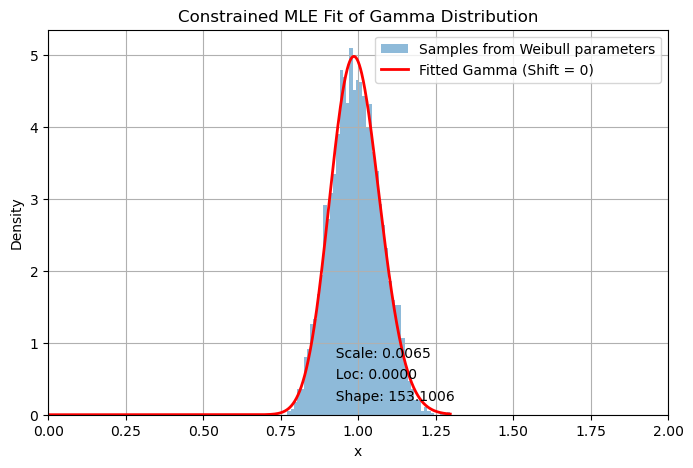

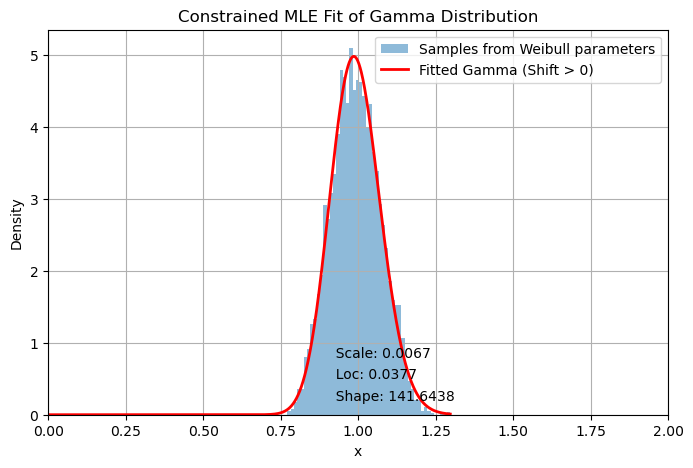

In [71]:
weibull_par = [0.2625,3.232,0.7581]

def gamma_nll(params, data):
    shape, loc, scale = params
    if shape <= 0 or scale <= 0:
        return np.inf  # invalid
    return -np.sum(gamma.logpdf(data, a=shape, loc=loc, scale=scale))

def gamma_fit2(weibull_par, tau_forced):
    np.random.seed(0)
    samples = weibull_min.rvs(c=weibull_par[1], scale=weibull_par[0], loc = weibull_par[2], size=5000)

    if tau_forced : 
        bounds = [
            (1e-5, None),   # shape > 0
            (0, 0),         # loc = 0
            (1e-5, None)    # scale > 0
        ]
        constraint = "Shift = 0"
    else:
        bounds = [
            (1e-5, None),   # shape > 0
            (0, 1),         # loc in [0, 1]
            (1e-5, None)    # scale > 0
        ]
        constraint = "Shift > 0"

    initial_guess = [1.0, 0.0, 1.0]

    result = minimize(
        gamma_nll,
        initial_guess,
        args=(samples,),
        method='Nelder-Mead',
        bounds=bounds,
        tol = 1e-3,
        options = {'maxiter': 20000}
    )

    if not result.success:
        raise RuntimeError("Optimization failed:", result.message)
    shape_fit, loc_fit, scale_fit = result.x

    x = np.linspace(0, max(samples), 1000)
    pdf_fit = gamma.pdf(x, a=shape_fit, loc=loc_fit, scale=scale_fit)

    plt.figure(figsize=(8, 5))
    plt.text(.9,0.2,f"  Shape: {shape_fit:.4f}")
    plt.text(.9,0.5,f"  Loc: {loc_fit:.4f}")
    plt.text(.9,0.8,f"  Scale: {scale_fit:.4f}")
    plt.hist(samples, bins=50, density=True, alpha=0.5, label="Samples from Weibull parameters")
    plt.plot(x, pdf_fit, 'r-', lw=2, label="Fitted Gamma (" + constraint + ")")
    plt.xlim(0,2)
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.title('Constrained MLE Fit of Gamma Distribution')
    plt.show()

gamma_fit2(weibull_par, True)
gamma_fit2(weibull_par, False)

### Un exemple de fit où le shift incompressible améliore grandement le fit : paramètres tirés de Teixeira et al. 2001

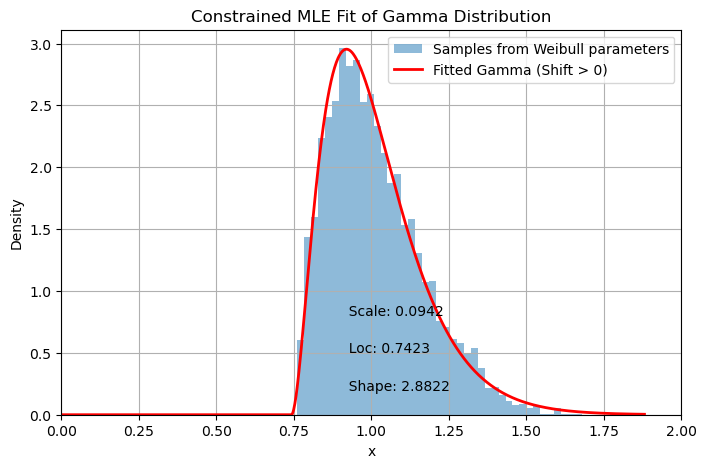

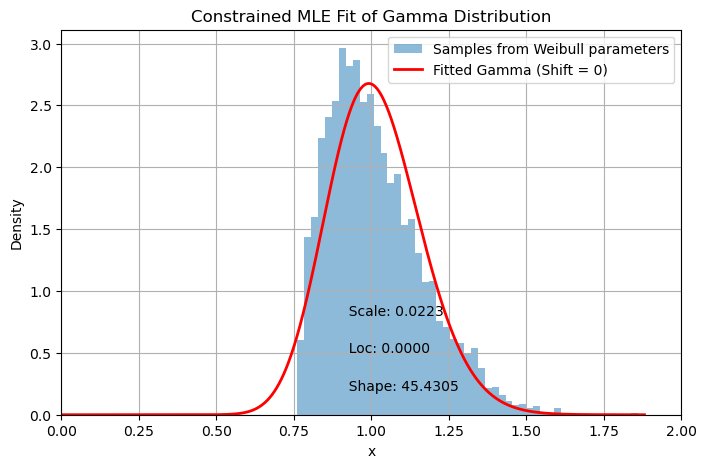

In [5]:
weibull_par = [0.2864,1.7037,0.7594]

gamma_fit2(weibull_par, False)
gamma_fit2(weibull_par, True)

KstestResult(statistic=0.015938483772125034, pvalue=0.15593185223326056, statistic_location=1.0748928880698534, statistic_sign=-1)


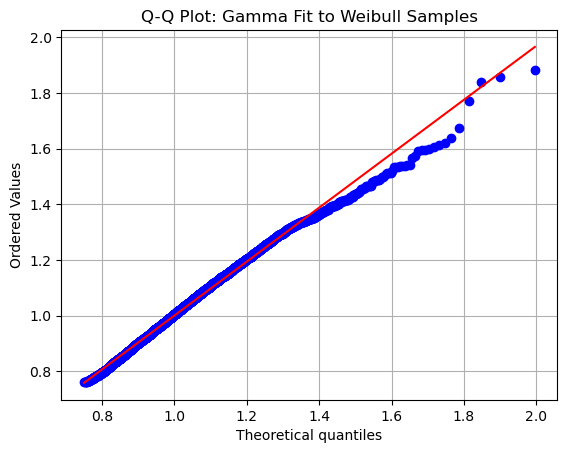

KstestResult(statistic=0.045284007855377006, pvalue=2.39013136477004e-09, statistic_location=0.9867589909139574, statistic_sign=1)


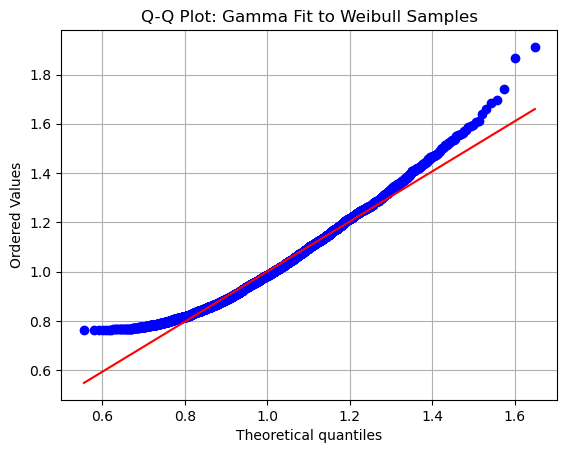

In [6]:
weibull_par = [0.2864,1.7037,0.7594]
np.random.seed(0)

samples = weibull_min.rvs(c=weibull_par[1], scale=weibull_par[0], loc = weibull_par[2], size=5000)
shape1, loc1, scale1 = gamma.fit(samples, method = "MLE")
test = kstest(samples, 'gamma', args=(shape1, loc1, scale1))
print(test)
gamma_params = [shape1, loc1, scale1]
probplot(samples, dist=gamma, sparams=gamma_params, plot=plt)
plt.title("Q-Q Plot: Gamma Fit to Weibull Samples")
plt.grid(True)
plt.show()

samples = weibull_min.rvs(c=weibull_par[1], scale=weibull_par[0], loc = weibull_par[2], size=5000)
shape1, loc1, scale1 = gamma.fit(samples, floc = 0, method = "MLE")
test = kstest(samples, 'gamma', args=(shape1, loc1, scale1))
print(test)
gamma_params = [shape1, loc1, scale1]
probplot(samples, dist=gamma, sparams=gamma_params, plot=plt)
plt.title("Q-Q Plot: Gamma Fit to Weibull Samples")
plt.grid(True)
plt.show()

# Fits multiples et répartition des paramètres shape obtenus : données Egg-Larva-Pupa (ou prePupa)

## Génération des fichiers de fit et de visualisation

D'abord en forçant $\tau = 0$

In [72]:
tau_forced = True

info_array = []
weibull_pars = []
with open(directory+'/Survey_staged.csv', newline="") as csvfile:
        reader = csv.reader(csvfile)
        for i,row in enumerate(reader):
            species = row[0]
            stage = row[1]
            scale0 = np.float32(row[2])
            shape0 = np.float32(row[3])
            loc0 = np.float32(row[4])
            if shape0>0:
                if loc0>=0:
                    weibull_pars.append([shape0, scale0, loc0])
                    info_array.append([species, stage])
weibull_pars = np.array(weibull_pars)
info_array = np.array(info_array)

if not os.path.exists(directory+'/Figures_fit_gamma'):
    os.mkdir(directory+'/Figures_fit_gamma')

gamma_pars = np.zeros(weibull_pars.shape)
for i,pars in enumerate(weibull_pars):
    np.random.seed(0)
    
    samples = weibull_min.rvs(c=pars[0], scale=pars[1], loc = pars[2], size=5000)

    if tau_forced : 
        bounds = [
            (1e-5, None),   # shape > 0
            (0, 0),         # loc = 0
            (1e-5, None)    # scale > 0
        ]
        constraint = "Shift = 0"
    else:
        bounds = [
            (1e-5, None),   # shape > 0
            (0, 1),         # loc in [0, 1]
            (1e-5, None)    # scale > 0
        ]
        constraint = "Shift > 0"

    initial_guess = [1.0, 0.0, 1.0]

    result = minimize(
        gamma_nll,
        initial_guess,
        args=(samples,),
        method='Nelder-Mead',
        bounds=bounds,
        tol = 1e-3,
        options = {'maxiter': 20000}
    )

    if not result.success:
        raise RuntimeError("Optimization failed:", result.message)
    shape_fit, loc_fit, scale_fit = result.x
    gamma_pars[i,:] = np.array([shape_fit, scale_fit, loc_fit])

    x = np.linspace(0, max(samples), 1000)
    pdf_fit = gamma.pdf(x, a=shape_fit, scale=scale_fit, loc=loc_fit)

    plt.figure(figsize=(8, 5))
    plt.text(.9,0.2,f"  Shape: {shape_fit:.4f}")
    plt.text(.9,0.5,f"  Loc: {loc_fit:.4f}")
    plt.text(.9,0.8,f"  Scale: {scale_fit:.4f}")
    plt.hist(samples, bins=50, density=True, alpha=0.5, label="Samples from Weibull parameters")
    plt.plot(x, pdf_fit, 'r-', lw=2, label="Fitted Gamma (" + constraint + ")")
    plt.xlim(0,2)
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.title(f"Weibull distribution of maturation time and Gamma fit \n for species {info_array[i,0]}, stage {info_array[i,1]}")
    plt.savefig(f"{directory}/Figures_fit_gamma/{info_array[i,0]}_{info_array[i,1]}.png")
    plt.close()

# Save results
np.save(directory+"/gamma_staged.npy", gamma_pars)
np.savetxt(directory+"/gamma_fit_per_stage.csv", gamma_pars, fmt="%10.4f",delimiter=",")

# Add header, add two columns giving species and stage
csv_file_path = directory+"/gamma_fit_per_stage.csv"

with open(csv_file_path, 'r') as file:
    reader = csv.reader(file)
    data = list(reader)

for i in range(0, len(data)):
    data[i].append(info_array[i,0])
    data[i].append(info_array[i,1])

with open(csv_file_path, 'w', newline='') as file:
    ### HEADER
    writer = csv.DictWriter(file, fieldnames = ["shape", "scale", "shift", "species", "stage"])
    writer.writeheader()

    ### data
    writer = csv.writer(file)
    writer.writerows(data)

Puis en posant $\tau \in [0;1]$

In [73]:
tau_forced = False

info_array = []
weibull_pars = []
with open(directory+'/Survey_staged.csv', newline="") as csvfile:
        reader = csv.reader(csvfile)
        for i,row in enumerate(reader):
            species = row[0]
            stage = row[1]
            scale0 = np.float32(row[2])
            shape0 = np.float32(row[3])
            loc0 = np.float32(row[4])
            if shape0>0:
                if loc0>=0:
                    weibull_pars.append([shape0, scale0, loc0])
                    info_array.append([species, stage])
weibull_pars = np.array(weibull_pars)
info_array = np.array(info_array)

if not os.path.exists(directory+'/Figures_fit_gamma_shift'):
    os.mkdir(directory+'/Figures_fit_gamma_shift')

gamma_pars_shift = np.zeros(weibull_pars.shape)
for i,pars in enumerate(weibull_pars):
    np.random.seed(0)
    
    samples = weibull_min.rvs(c=pars[0], scale=pars[1], loc = pars[2], size=5000)

    if tau_forced : 
        bounds = [
            (1e-5, None),   # shape > 0
            (0, 0),         # loc = 0
            (1e-5, None)    # scale > 0
        ]
        constraint = "Shift = 0"
    else:
        bounds = [
            (1e-5, None),   # shape > 0
            (0, 1),         # loc in [0, 1]
            (1e-5, None)    # scale > 0
        ]
        constraint = "Shift > 0"

    initial_guess = [1.0, 0.0, 1.0]

    result = minimize(
        gamma_nll,
        initial_guess,
        args=(samples,),
        method='Nelder-Mead',
        bounds=bounds,
        tol = 1e-3,
        options = {'maxiter': 20000}
    )

    if not result.success:
        raise RuntimeError("Optimization failed:", result.message)
    shape_fit, loc_fit, scale_fit = result.x
    gamma_pars_shift[i,:] = np.array([shape_fit, scale_fit, loc_fit])

    x = np.linspace(0, max(samples), 1000)
    pdf_fit = gamma.pdf(x, a=shape_fit, loc=loc_fit, scale=scale_fit)

    plt.figure(figsize=(8, 5))
    plt.text(.9,0.2,f"  Shape: {shape_fit:.4f}")
    plt.text(.9,0.5,f"  Loc: {loc_fit:.4f}")
    plt.text(.9,0.8,f"  Scale: {scale_fit:.4f}")
    plt.hist(samples, bins=50, density=True, alpha=0.5, label="Samples from Weibull parameters")
    plt.plot(x, pdf_fit, 'r-', lw=2, label="Fitted Gamma (" + constraint + ")")
    plt.xlim(0,2)
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.title(f"Weibull distribution of maturation time and Gamma fit \n for species {info_array[i,0]}, stage {info_array[i,1]}")
    plt.savefig(f"{directory}/Figures_fit_gamma_shift/{info_array[i,0]}_{info_array[i,1]}.png")
    plt.close()

# Save results
np.save(directory+"/gamma_staged_shifted.npy", gamma_pars_shift) # .npy file
np.savetxt(directory+"/gamma_fit_per_stage_shifted.csv", gamma_pars_shift, fmt="%10.4f",delimiter=",") # .csv file

# Add header, add two columns giving species and stage
csv_file_path = directory+"/gamma_fit_per_stage_shifted.csv"

with open(csv_file_path, 'r') as file:
    reader = csv.reader(file)
    data = list(reader)

for i in range(0, len(data)):
    data[i].append(info_array[i,0])
    data[i].append(info_array[i,1])

with open(csv_file_path, 'w', newline='') as file:
    ### HEADER
    writer = csv.DictWriter(file, fieldnames = ["shape", "scale", "shift", "species", "stage"])
    writer.writeheader()

    ### data
    writer = csv.writer(file)
    writer.writerows(data)

## Visualisation des résultats - Histogrammes

In [94]:
with open(directory+'/gamma_staged.npy', 'rb') as f:
    gamma_pars = np.load(f)
with open(directory+'/gamma_staged_shifted.npy', 'rb') as f:
    gamma_pars_shifted = np.load(f)

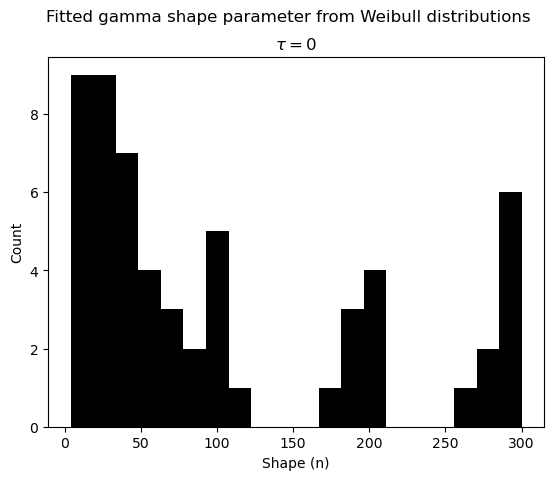

In [75]:
data = gamma_pars[:,0].astype(int)
data = np.clip(data,0,300)
plt.hist(data, bins = 20, color = "black")
plt.suptitle("Fitted gamma shape parameter from Weibull distributions")
plt.title(r"$\tau = 0$")
plt.xlabel("Shape (n)")
plt.ylabel("Count")
plt.show()

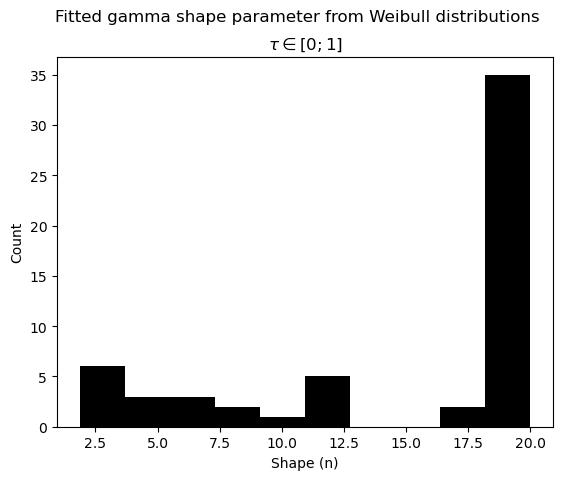

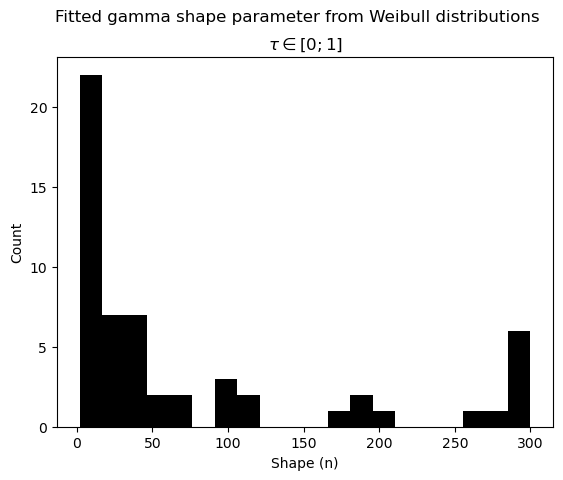

In [76]:
datasd = gamma_pars_shifted[:,0]
datasd = np.clip(datasd, 0,20)
plt.hist(datasd, bins = 10, color = "black")
plt.xlabel("Shape (n)")
plt.ylabel("Count")
plt.suptitle("Fitted gamma shape parameter from Weibull distributions")
plt.title(r"$\tau \in [0;1]$")
plt.show()

datasd = gamma_pars_shifted[:,0]
datasd = np.clip(datasd, 0,300)
plt.hist(datasd, bins = 20, color = "black")
plt.xlabel("Shape (n)")
plt.ylabel("Count")
plt.suptitle("Fitted gamma shape parameter from Weibull distributions")
plt.title(r"$\tau \in [0;1]$")
plt.show()

On a reproduit ce groupe de n < 20 qu'on voit beaucoup moins quand on force l'absence de pré-délai fixe

## Visualisation des résultats - Violinplot et effet du forçage $\tau = 0$

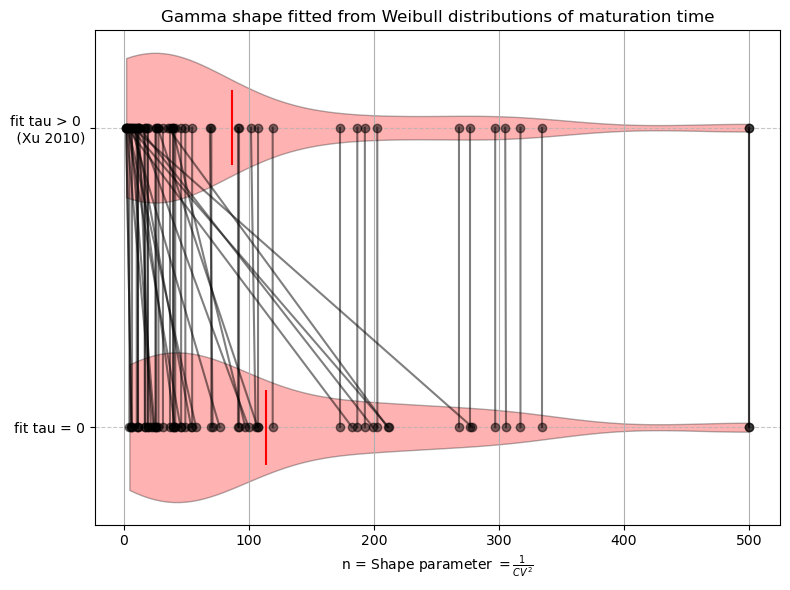

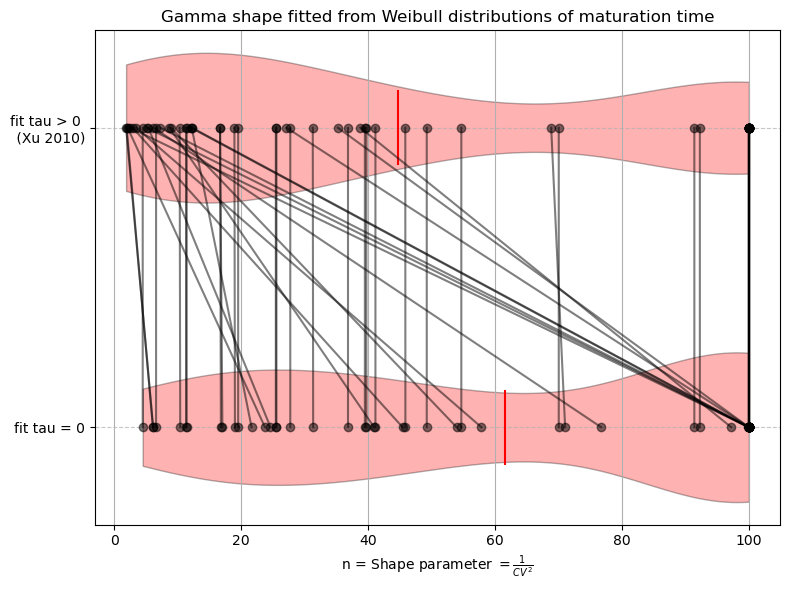

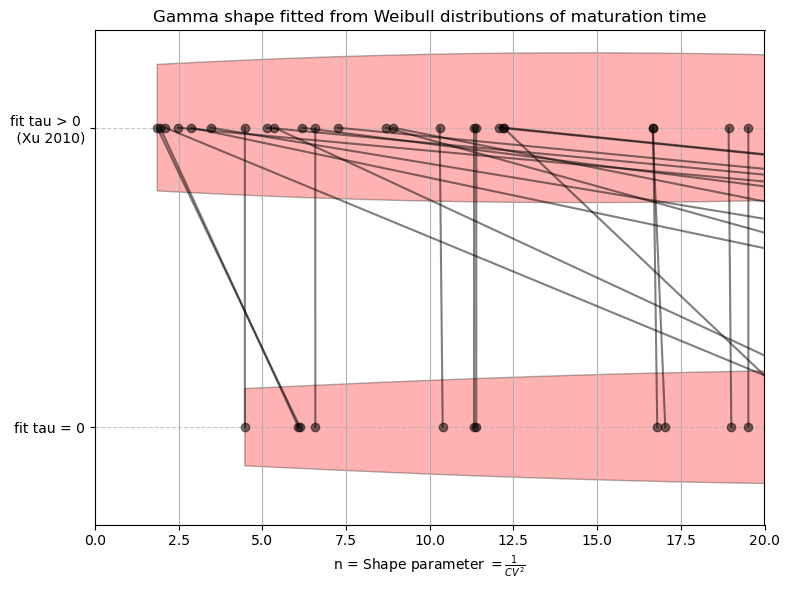

In [109]:
data1 = np.clip(gamma_pars[:,0], 0, 500)
data2 = np.clip(gamma_pars_shifted[:,0], 0, 500)

data = [data1, data2]

# Plot boxplots
fig, ax = plt.subplots(figsize=(8, 6))
box = ax.violinplot(data, vert=False, positions=[1, 2], widths=0.5, showmeans=True, showmedians=False, showextrema=False)
for pc in box['bodies']:
    pc.set_facecolor('red')
    pc.set_edgecolor('black')
box['cmeans'].set_colors('red')

# Plot lines connecting paired data points
for i in range(len(data1)):
    ax.plot([data1[i], data2[i]], [1, 2],color='black', alpha=0.5, marker='o')

# Aesthetic settings
ax.set_yticks([1, 2])
ax.set_yticklabels(['fit tau = 0', 'fit tau > 0 \n (Xu 2010)'])
ax.set_xlabel(r'n = Shape parameter $= \frac{1}{CV^2}$')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.grid(True)
plt.show()


### ZOOM ### 
data1 = np.clip(gamma_pars[:,0], 0, 100)
data2 = np.clip(gamma_pars_shifted[:,0], 0, 100)

data = [data1, data2]

# Plot boxplots
fig, ax = plt.subplots(figsize=(8, 6))
box = ax.violinplot(data, vert=False, positions=[1, 2], widths=0.5, showmeans=True, showmedians=False, showextrema=False)
for pc in box['bodies']:
    pc.set_facecolor('red')
    pc.set_edgecolor('black')
box['cmeans'].set_colors('red')

# Plot lines connecting paired data points
for i in range(len(data1)):
    ax.plot([data1[i], data2[i]], [1, 2],color='black', alpha=0.5, marker='o')

# Aesthetic settings
ax.set_yticks([1, 2])
ax.set_yticklabels(['fit tau = 0', 'fit tau > 0 \n (Xu 2010)'])
ax.set_xlabel(r'n = Shape parameter $= \frac{1}{CV^2}$')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.grid(True)
plt.show()

### ZOOM ### 
data1 = np.clip(gamma_pars[:,0], 0, 100)
data2 = np.clip(gamma_pars_shifted[:,0], 0, 100)

data = [data1, data2]

# Plot boxplots
fig, ax = plt.subplots(figsize=(8, 6))
box = ax.violinplot(data, vert=False, positions=[1, 2], widths=0.5, showmeans=True, showmedians=False, showextrema=False)
for pc in box['bodies']:
    pc.set_facecolor('red')
    pc.set_edgecolor('black')
box['cmeans'].set_colors('red')

# Plot lines connecting paired data points
for i in range(len(data1)):
    ax.plot([data1[i], data2[i]], [1, 2],color='black', alpha=0.5, marker='o')

# Aesthetic settings
ax.set_xlim(0,20)
ax.set_yticks([1, 2])
ax.set_yticklabels(['fit tau = 0', 'fit tau > 0 \n (Xu 2010)'])
ax.set_xlabel(r'n = Shape parameter $= \frac{1}{CV^2}$')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.grid(True)
plt.show()

# Fits multiples et répartition des paramètres shape obtenus : données whole development

## Génération des fichiers de fit et de visualisation

In [78]:
tau_forced = True

info_array = []
weibull_pars = []
with open(directory+'/Survey_total_juvenile.csv', newline="") as csvfile:
        reader = csv.reader(csvfile)
        for i,row in enumerate(reader):
            species = row[0]
            stage = row[1]
            scale0 = np.float32(row[2])
            shape0 = np.float32(row[3])
            loc0 = np.float32(row[4])
            if shape0>0:
                if loc0>=0:
                    weibull_pars.append([shape0, scale0, loc0])
                    info_array.append([species, stage])
weibull_pars = np.array(weibull_pars)
info_array = np.array(info_array)

if not os.path.exists(directory+'/Figures_fit_gamma_total'):
    os.mkdir(directory+'/Figures_fit_gamma_total')

gamma_pars_total = np.zeros(weibull_pars.shape)
for i,pars in enumerate(weibull_pars):
    np.random.seed(0)
    
    samples = weibull_min.rvs(c=pars[0], scale=pars[1], loc = pars[2], size=5000)

    if tau_forced : 
        bounds = [
            (1e-5, None),   # shape > 0
            (0, 0),         # loc = 0
            (1e-5, None)    # scale > 0
        ]
        constraint = "Shift = 0"
    else:
        bounds = [
            (1e-5, None),   # shape > 0
            (0, 1),         # loc in [0, 1]
            (1e-5, None)    # scale > 0
        ]
        constraint = "Shift > 0"

    initial_guess = [1.0, 0.0, 1.0]

    result = minimize(
        gamma_nll,
        initial_guess,
        args=(samples,),
        method='Nelder-Mead',
        bounds=bounds,
        tol = 1e-3,
        options = {'maxiter': 20000}
    )

    if not result.success:
        raise RuntimeError("Optimization failed:", result.message)
    shape_fit, loc_fit, scale_fit = result.x
    gamma_pars_total[i,:] = np.array([shape_fit, scale_fit, loc_fit])

    x = np.linspace(0, max(samples), 1000)
    pdf_fit = gamma.pdf(x, a=shape_fit, loc=loc_fit, scale=scale_fit)

    plt.figure(figsize=(8, 5))
    plt.text(.9,0.2,f"  Shape: {shape_fit:.4f}")
    plt.text(.9,0.5,f"  Loc: {loc_fit:.4f}")
    plt.text(.9,0.8,f"  Scale: {scale_fit:.4f}")
    plt.hist(samples, bins=50, density=True, alpha=0.5, label="Samples from Weibull parameters")
    plt.plot(x, pdf_fit, 'r-', lw=2, label="Fitted Gamma (" + constraint + ")")
    plt.xlim(0,2)
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.title(f"Weibull distribution of maturation time and Gamma fit \n for species {info_array[i,0]}, stage {info_array[i,1]}")
    plt.savefig(f"{directory}/Figures_fit_gamma_total/{info_array[i,0]}_{info_array[i,1]}.png")
    plt.close()


# Save results
np.save(directory+"/gamma_total_dev.npy", gamma_pars_total)
np.savetxt(directory+"/gamma_fit_total_dev.csv", gamma_pars_total, fmt="%10.4f",delimiter=",") # .csv file

# Add header, add two columns giving species and stage
csv_file_path = directory+"/gamma_fit_total_dev.csv"

with open(csv_file_path, 'r') as file:
    reader = csv.reader(file)
    data = list(reader)

for i in range(0, len(data)):
    data[i].append(info_array[i,0])
    data[i].append(info_array[i,1])

with open(csv_file_path, 'w', newline='') as file:
    ### HEADER
    writer = csv.DictWriter(file, fieldnames = ["shape", "scale", "shift", "species", "info"])
    writer.writeheader()

    ### data
    writer = csv.writer(file)
    writer.writerows(data)

In [79]:
tau_forced = False

info_array = []
weibull_pars = []
with open(directory+'/Survey_total_juvenile.csv', newline="") as csvfile:
        reader = csv.reader(csvfile)
        for i,row in enumerate(reader):
            species = row[0]
            stage = row[1]
            scale0 = np.float32(row[2])
            shape0 = np.float32(row[3])
            loc0 = np.float32(row[4])
            if shape0>0:
                if loc0>=0:
                    weibull_pars.append([shape0, scale0, loc0])
                    info_array.append([species, stage])
weibull_pars = np.array(weibull_pars)
info_array = np.array(info_array)

if not os.path.exists(directory+'/Figures_fit_gamma_total_shifted'):
    os.mkdir(directory+'/Figures_fit_gamma_total_shifted')

gamma_pars_total_shift = np.zeros(weibull_pars.shape)
for i,pars in enumerate(weibull_pars):
    np.random.seed(0)
    
    samples = weibull_min.rvs(c=pars[0], scale=pars[1], loc = pars[2], size=5000)

    if tau_forced : 
        bounds = [
            (1e-5, None),   # shape > 0
            (0, 0),         # loc = 0
            (1e-5, None)    # scale > 0
        ]
        constraint = "Shift = 0"
    else:
        bounds = [
            (1e-5, None),   # shape > 0
            (0, 1),         # loc in [0, 1]
            (1e-5, None)    # scale > 0
        ]
        constraint = "Shift > 0"

    initial_guess = [1.0, 0.0, 1.0]

    result = minimize(
        gamma_nll,
        initial_guess,
        args=(samples,),
        method='Nelder-Mead',
        bounds=bounds,
        tol = 1e-3,
        options = {'maxiter': 20000}
    )

    if not result.success:
        raise RuntimeError("Optimization failed:", result.message)
    shape_fit, loc_fit, scale_fit = result.x
    gamma_pars_total_shift[i,:] = np.array([shape_fit, scale_fit, loc_fit])

    x = np.linspace(0, max(samples), 1000)
    pdf_fit = gamma.pdf(x, a=shape_fit, loc=loc_fit, scale=scale_fit)

    plt.figure(figsize=(8, 5))
    plt.text(.9,0.2,f"  Shape: {shape_fit:.4f}")
    plt.text(.9,0.5,f"  Loc: {loc_fit:.4f}")
    plt.text(.9,0.8,f"  Scale: {scale_fit:.4f}")
    plt.hist(samples, bins=50, density=True, alpha=0.5, label="Samples from Weibull parameters")
    plt.plot(x, pdf_fit, 'r-', lw=2, label="Fitted Gamma (" + constraint + ")")
    plt.xlim(0,2)
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.title(f"Weibull distribution of maturation time and Gamma fit \n for species {info_array[i,0]}, stage {info_array[i,1]}")
    plt.savefig(f"{directory}/Figures_fit_gamma_total_shifted/{info_array[i,0]}_{info_array[i,1]}.png")
    plt.close()


# Save results
np.save(directory+"/gamma_total_dev_shifted.npy", gamma_pars_total_shift)
np.savetxt(directory+"/gamma_fit_total_dev_shifted.csv", gamma_pars_total_shift, fmt="%10.4f",delimiter=",") # .csv file

# Add header, add two columns giving species and stage
csv_file_path = directory+"/gamma_fit_total_dev_shifted.csv"

with open(csv_file_path, 'r') as file:
    reader = csv.reader(file)
    data = list(reader)

for i in range(0, len(data)):
    data[i].append(info_array[i,0])
    data[i].append(info_array[i,1])

with open(csv_file_path, 'w', newline='') as file:
    ### HEADER
    writer = csv.DictWriter(file, fieldnames = ["shape", "scale", "shift", "species", "info"])
    writer.writeheader()

    ### data
    writer = csv.writer(file)
    writer.writerows(data)

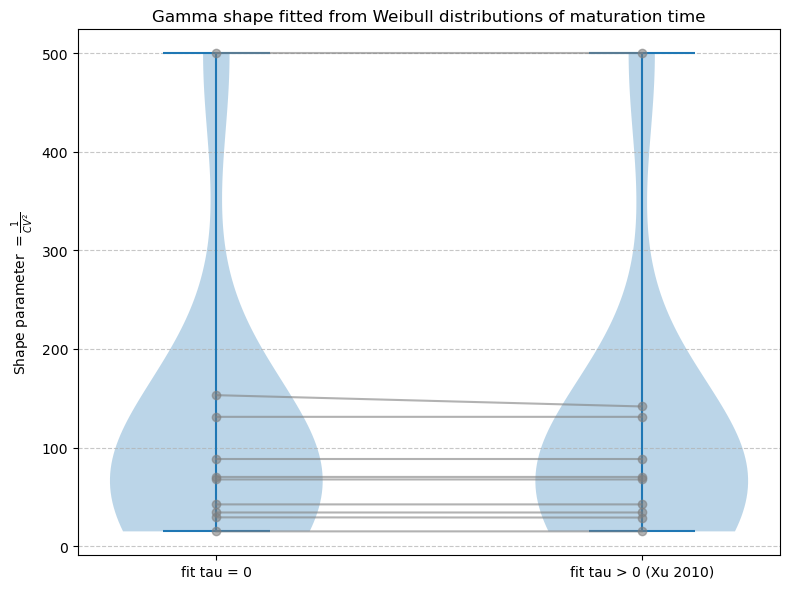

In [80]:
with open(directory+'/gamma_total_dev.npy', 'rb') as f:
    gamma_pars = np.load(f)
with open(directory+'/gamma_total_dev_shifted.npy', 'rb') as f:
    gamma_pars_shifted = np.load(f)

data1 = np.clip(gamma_pars_total[:,0], 0, 500)
data2 = np.clip(gamma_pars_total_shift[:,0], 0, 500)

data = [data1, data2]

# Plot boxplots
fig, ax = plt.subplots(figsize=(8, 6))
box = ax.violinplot(data, positions=[1, 2], widths=0.5)

# Plot lines connecting paired data points
for i in range(len(data1)):
    ax.plot([1, 2], [data1[i], data2[i]], color='gray', alpha=0.6, marker='o')

# Aesthetic settings
ax.set_xticks([1, 2])
ax.set_xticklabels(['fit tau = 0', 'fit tau > 0 (Xu 2010)'])
ax.set_ylabel(r'Shape parameter $= \frac{1}{CV^2}$')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



# Fits multiples et répartition des paramètres shape obtenus : données substage

## Génération des fichiers de fit et de visualisation

In [112]:
tau_forced = True

info_array = []
weibull_pars = []
with open(directory+'/Survey_substaged.csv', newline="") as csvfile:
        reader = csv.reader(csvfile)
        for i,row in enumerate(reader):
            species = row[0]
            stage = row[1]
            scale0 = np.float32(row[2])
            shape0 = np.float32(row[3])
            loc0 = np.float32(row[4])
            if shape0>0:
                if loc0>=0:
                    weibull_pars.append([shape0, scale0, loc0])
                    info_array.append([species, stage])
weibull_pars = np.array(weibull_pars)
info_array = np.array(info_array)

if not os.path.exists(directory+'/Figures_fit_gamma_substaged'):
    os.mkdir(directory+'/Figures_fit_gamma_substaged')

gamma_pars_substaged = np.zeros(weibull_pars.shape)
for i,pars in enumerate(weibull_pars):
    np.random.seed(0)
    
    samples = weibull_min.rvs(c=pars[0], scale=pars[1], loc = pars[2], size=5000)

    if tau_forced : 
        bounds = [
            (1e-5, None),   # shape > 0
            (0, 0),         # loc = 0
            (1e-5, None)    # scale > 0
        ]
        constraint = "Shift = 0"
    else:
        bounds = [
            (1e-5, None),   # shape > 0
            (0, 1),         # loc in [0, 1]
            (1e-5, None)    # scale > 0
        ]
        constraint = "Shift > 0"

    initial_guess = [1.0, 0.0, 1.0]

    result = minimize(
        gamma_nll,
        initial_guess,
        args=(samples,),
        method='Nelder-Mead',
        bounds=bounds,
        tol = 1e-3,
        options = {'maxiter': 20000}
    )

    if not result.success:
        raise RuntimeError("Optimization failed:", result.message)
    shape_fit, loc_fit, scale_fit = result.x
    gamma_pars_substaged[i,:] = np.array([shape_fit, scale_fit, loc_fit])

    x = np.linspace(0, max(samples), 1000)
    pdf_fit = gamma.pdf(x, a=shape_fit, loc=loc_fit, scale=scale_fit)

    plt.figure(figsize=(8, 5))
    plt.text(.9,0.2,f"  Shape: {shape_fit:.4f}")
    plt.text(.9,0.5,f"  Loc: {loc_fit:.4f}")
    plt.text(.9,0.8,f"  Scale: {scale_fit:.4f}")
    plt.hist(samples, bins=50, density=True, alpha=0.5, label="Samples from Weibull parameters")
    plt.plot(x, pdf_fit, 'r-', lw=2, label="Fitted Gamma (" + constraint + ")")
    plt.xlim(0,2)
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.title(f"Weibull distribution of maturation time and Gamma fit \n for species {info_array[i,0]}, stage {info_array[i,1]}")
    plt.savefig(f"{directory}/Figures_fit_gamma_substaged/{info_array[i,0]}_{info_array[i,1]}.png")
    plt.close()


# Save results
np.save(directory+"/gamma_substaged.npy", gamma_pars_substaged)
np.savetxt(directory+"/gamma_fit_substaged.csv", gamma_pars_substaged, fmt="%10.4f",delimiter=",") # .csv file

# Add header, add two columns giving species and stage
csv_file_path = directory+"/gamma_fit_substaged.csv"

with open(csv_file_path, 'r') as file:
    reader = csv.reader(file)
    data = list(reader)

for i in range(0, len(data)):
    data[i].append(info_array[i,0])
    data[i].append(info_array[i,1])

with open(csv_file_path, 'w', newline='') as file:
    ### HEADER
    writer = csv.DictWriter(file, fieldnames = ["shape", "scale", "shift", "species", "info"])
    writer.writeheader()

    ### data
    writer = csv.writer(file)
    writer.writerows(data)

In [114]:
tau_forced = False

info_array = []
weibull_pars = []
with open(directory+'/Survey_substaged.csv', newline="") as csvfile:
        reader = csv.reader(csvfile)
        for i,row in enumerate(reader):
            species = row[0]
            stage = row[1]
            scale0 = np.float32(row[2])
            shape0 = np.float32(row[3])
            loc0 = np.float32(row[4])
            if shape0>0:
                if loc0>=0:
                    weibull_pars.append([shape0, scale0, loc0])
                    info_array.append([species, stage])
weibull_pars = np.array(weibull_pars)
info_array = np.array(info_array)

if not os.path.exists(directory+'/Figures_fit_gamma_substaged_shifted'):
    os.mkdir(directory+'/Figures_fit_gamma_substaged_shifted')

gamma_pars_substaged_shifted = np.zeros(weibull_pars.shape)
for i,pars in enumerate(weibull_pars):
    np.random.seed(0)
    
    samples = weibull_min.rvs(c=pars[0], scale=pars[1], loc = pars[2], size=5000)

    if tau_forced : 
        bounds = [
            (1e-5, None),   # shape > 0
            (0, 0),         # loc = 0
            (1e-5, None)    # scale > 0
        ]
        constraint = "Shift = 0"
    else:
        bounds = [
            (1e-5, None),   # shape > 0
            (0, 1),         # loc in [0, 1]
            (1e-5, None)    # scale > 0
        ]
        constraint = "Shift > 0"

    initial_guess = [1.0, 0.0, 1.0]

    result = minimize(
        gamma_nll,
        initial_guess,
        args=(samples,),
        method='Nelder-Mead',
        bounds=bounds,
        tol = 1e-3,
        options = {'maxiter': 20000}
    )

    if not result.success:
        raise RuntimeError("Optimization failed:", result.message)
    shape_fit, loc_fit, scale_fit = result.x
    gamma_pars_substaged_shifted[i,:] = np.array([shape_fit, scale_fit, loc_fit])

    x = np.linspace(0, max(samples), 1000)
    pdf_fit = gamma.pdf(x, a=shape_fit, loc=loc_fit, scale=scale_fit)

    plt.figure(figsize=(8, 5))
    plt.text(.9,0.2,f"  Shape: {shape_fit:.4f}")
    plt.text(.9,0.5,f"  Loc: {loc_fit:.4f}")
    plt.text(.9,0.8,f"  Scale: {scale_fit:.4f}")
    plt.hist(samples, bins=50, density=True, alpha=0.5, label="Samples from Weibull parameters")
    plt.plot(x, pdf_fit, 'r-', lw=2, label="Fitted Gamma (" + constraint + ")")
    plt.xlim(0,2)
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.title(f"Weibull distribution of maturation time and Gamma fit \n for species {info_array[i,0]}, stage {info_array[i,1]}")
    plt.savefig(f"{directory}/Figures_fit_gamma_substaged_shifted/{info_array[i,0]}_{info_array[i,1]}.png")
    plt.close()


# Save results
np.save(directory+"/gamma_substaged_shifted.npy", gamma_pars_substaged_shifted)
np.savetxt(directory+"/gamma_fit_substaged_shifted.csv", gamma_pars_substaged_shifted, fmt="%10.4f",delimiter=",") # .csv file

# Add header, add two columns giving species and stage
csv_file_path = directory+"/gamma_fit_substaged_shifted.csv"

with open(csv_file_path, 'r') as file:
    reader = csv.reader(file)
    data = list(reader)

for i in range(0, len(data)):
    data[i].append(info_array[i,0])
    data[i].append(info_array[i,1])

with open(csv_file_path, 'w', newline='') as file:
    ### HEADER
    writer = csv.DictWriter(file, fieldnames = ["shape", "scale", "shift", "species", "info"])
    writer.writeheader()

    ### data
    writer = csv.writer(file)
    writer.writerows(data)

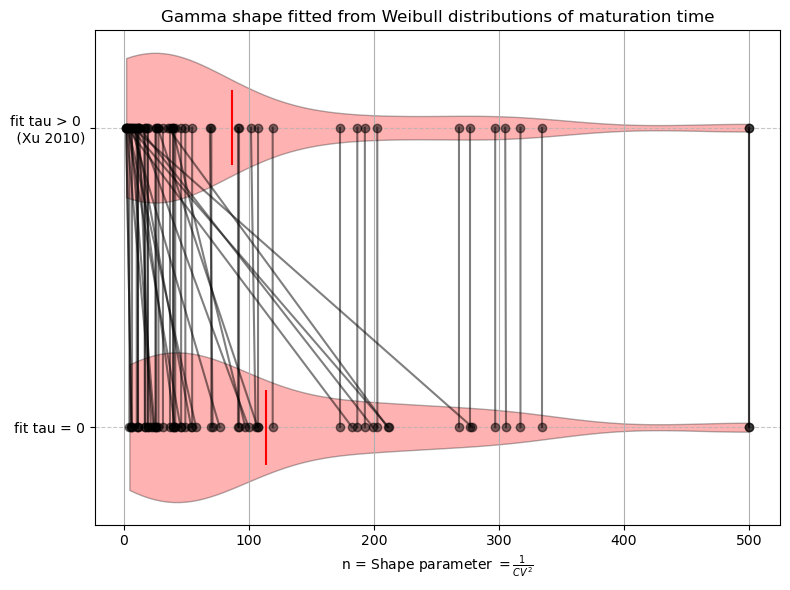

In [115]:
data1 = np.clip(gamma_pars_substaged[:,0], 0, 500)
data2 = np.clip(gamma_pars_substaged_shifted[:,0], 0, 500)

data = [data1, data2]

# Plot boxplots
fig, ax = plt.subplots(figsize=(8, 6))
box = ax.violinplot(data, vert=False, positions=[1, 2], widths=0.5, showmeans=True, showmedians=False, showextrema=False)
for pc in box['bodies']:
    pc.set_facecolor('red')
    pc.set_edgecolor('black')
box['cmeans'].set_colors('red')

# Plot lines connecting paired data points
for i in range(len(data1)):
    ax.plot([data1[i], data2[i]], [1, 2],color='black', alpha=0.5, marker='o')

# Aesthetic settings
ax.set_yticks([1, 2])
ax.set_yticklabels(['fit tau = 0', 'fit tau > 0 \n (Xu 2010)'])
ax.set_xlabel(r'n = Shape parameter $= \frac{1}{CV^2}$')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.grid(True)
plt.show()

# Différences ensemble du dev - stade du dev

## Un exemple avec Wagner et al 1988

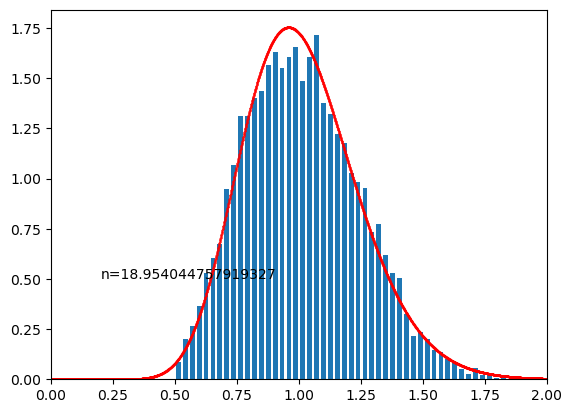

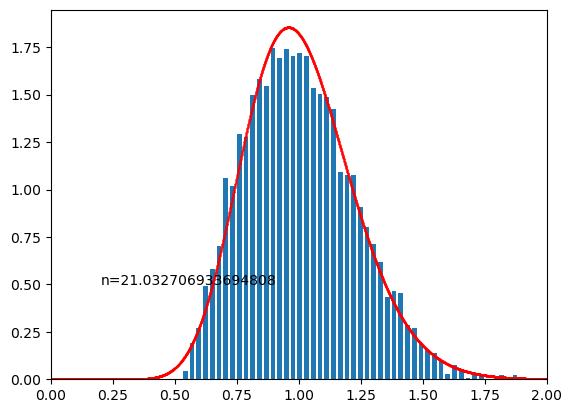

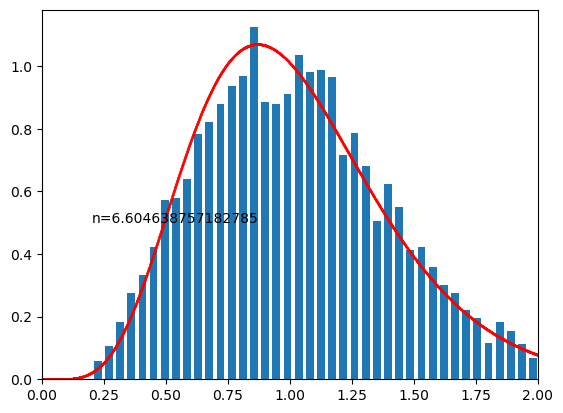

In [45]:
weibull_pars = np.array([[2.4737,0.6045, 0.4788], [2.4245, 0.5568, 0.5177], [2.3917, 0.9783, 0.1636]])

for i,pars in enumerate(weibull_pars):
    samples = weibull_min.rvs(c=weibull_pars[i,0], scale=weibull_pars[i,1], loc = weibull_pars[i,2], size=5000)

    histW, binsW = np.histogram(samples, bins=50,density=True)
    widthW = 0.7 * (binsW[1] - binsW[0])
    centerW = (binsW[:-1] + binsW[1:]) / 2
    plt.bar(centerW, histW, align='center', width=widthW, zorder=1)

    shape1, loc1, scale1 = gamma.fit(samples, floc = 0, method = "MLE")
    pdfgamma = gamma.pdf(np.linspace(0,2,5000), a = shape1, loc = loc1, scale = scale1)
    plt.scatter(np.linspace(0,2,5000), pdfgamma, s=.1, color = "red")
    plt.xlim(0,2)
    plt.text(0.2,0.5,f'n={shape1}')
    plt.show()


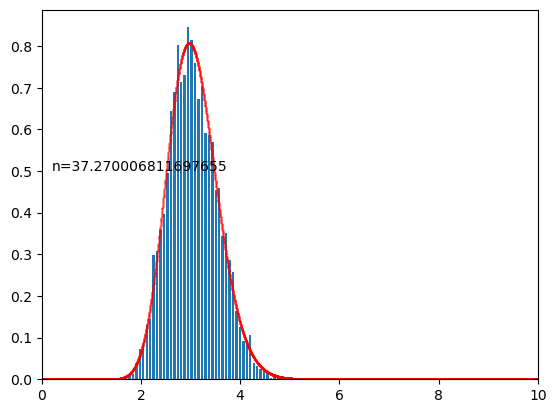

In [47]:
weibull_pars = np.array([[2.4737,0.6045, 0.4788], [2.4245, 0.5568, 0.5177], [2.3917, 0.9783, 0.1636]])

samples = np.zeros(5000)
for i,pars in enumerate(weibull_pars):
    samples += weibull_min.rvs(c=weibull_pars[i,0], scale=weibull_pars[i,1], loc = weibull_pars[i,2], size=5000)

histW, binsW = np.histogram(samples, bins=50,density=True)
widthW = 0.7 * (binsW[1] - binsW[0])
centerW = (binsW[:-1] + binsW[1:]) / 2
plt.bar(centerW, histW, align='center', width=widthW, zorder=1)

shape1, loc1, scale1 = gamma.fit(samples, floc = 0, method = "MLE")
pdfgamma = gamma.pdf(np.linspace(0,10,5000), a = shape1, loc = loc1, scale = scale1)
plt.scatter(np.linspace(0,10,5000), pdfgamma, s=.1, color = "red")
plt.xlim(0,10)
plt.text(0.2,0.5,f'n={shape1}')
plt.show()

Whole cycle given in paper (but we previously ignored adult stage):

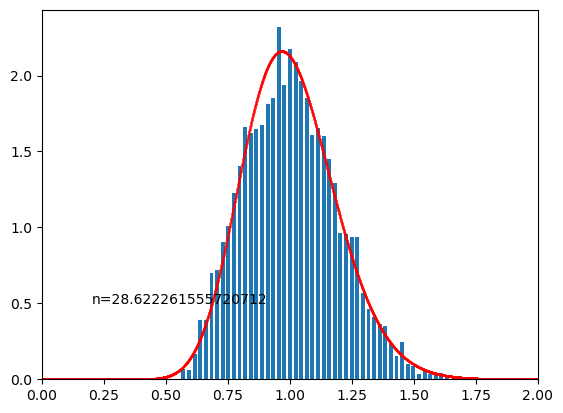

In [48]:
weibull_par = [0.5260,2.7306,0.5371]
gamma_fit(weibull_par)

## Gamma shapes fittées quand les données par stage et sur tout le développement sont disponibles

- Ips avulsus
- Cnaphalocrocis medinalis
- Amblyesius womersleyi
- Feltiella acarisuga
- Neoseiulus californicus

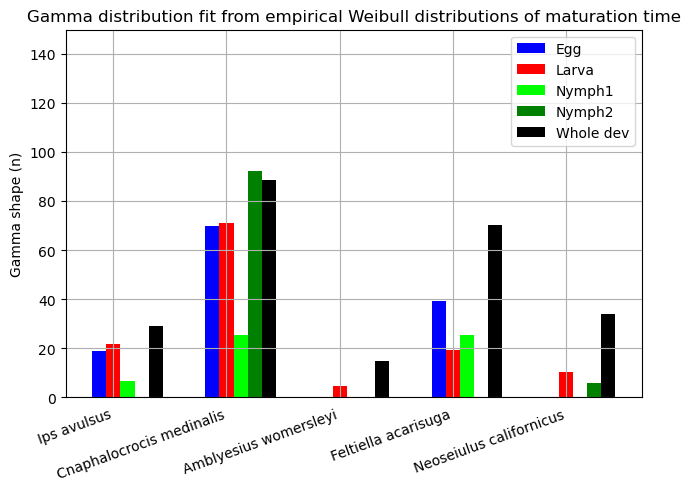

In [111]:
species = ("Ips avulsus", "Cnaphalocrocis medinalis", "Amblyesius womersleyi", "Feltiella acarisuga", "Neoseiulus californicus")
gamma_pars_dic = {
    'Egg': (19.00, 70.04, 0, 39.48, 0),
    'Larva': (21.63, 71.04, 4.47, 19.51, 10.38),
    'Nymph1': (6.58, 25.55, 0, 25.45, 0),
    'Nymph2': (0,92.27,0,0, 6.07),
    'Whole dev': (29.11, 88.74, 14.90, 70.14, 34.07)
}

# 'Sum of stage shapes' : (47.21, 0, 285.37,  0, 10.38)
x = 1.2*np.arange(len(species))  # the label locations
width = 0.15  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')
colors = ["blue", "red", "lime", "green", "black"]
for attribute, measurement in gamma_pars_dic.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color = colors[int(multiplier)])
    # ax.bar_label(rects, padding=5)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Gamma shape (n)')
ax.set_title('Gamma distribution fit from empirical Weibull distributions of maturation time')
ax.set_xticks(x + width, species)
ax.legend(loc='upper right', ncols=1)
ax.set_ylim(0, 150)
plt.xticks(rotation=20, ha='right')
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False)
plt.grid(True)
plt.show()


Pour A.womersleyi et N. californicus : données manquantes à causes des shifts négatifs dans les données Weibull